# Final Project Bootcamp Data Science HIMTI 2026 (Customer Churn Prediction System)

Selamat datang di fase *Predictive Analytics*! Hari ini kita akan membangun sistem deteksi dini untuk menemukan pelanggan yang berisiko **Churn** (berhenti berlangganan) sebelum mereka benar-benar pergi.

### Metodologi Standar Industri: CRISP-DM
1. **Business Understanding:** Mendefinisikan masalah bisnis dan tujuan ML.
2. **Data Understanding:** Audit anatomi data dan visualisasi pola.
3. **Data Preparation:** Menangani missing value, encoding, imbalance, dan *Data Splitting*.
4. **Modeling:** Melatih dan membedah cara kerja algoritma klasifikasi.
5. **Evaluation:** Mengukur performa model dengan metrik klasifikasi.

---
###  Peta Target Proyek Ini
| # | Yang Dikerjakan | Di Mana |
|---|-----------------|---------|
| **Tugas 1** | Deteksi profil pelanggan berisiko churn | BAB 2 |
| **Tugas 2** | Tangani class imbalance dengan SMOTE | BAB 3.5 |
| **Tugas 3** | Recall ≥ 80% pada Test Set | BAB 5 |
| Tambahan 1 | Simulasi kerugian finansial FN vs FP | BAB 6 |
| Tambahan 2 | Rekomendasi bisnis otomatis per segmen | BAB 7 |

In [1]:
# Import library standar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import library Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score, roc_auc_score, roc_curve

# Import library untuk menangani Class Imbalance
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
print("✅ Library Machine Learning siap digunakan!")

✅ Library Machine Learning siap digunakan!


## BAB 1: Business Understanding

**Studi Kasus: Deteksi Churn Pelanggan E-Commerce**

Platform e-commerce menghadapi ancaman senyap: pelanggan yang diam-diam berhenti berbelanja. Biaya akuisisi pelanggan baru **5–7x lebih mahal** dibandingkan mempertahankan pelanggan lama.

* **Tujuan:** Membangun model yang bisa mendeteksi pelanggan berisiko churn secara otomatis berdasarkan histori transaksi, keluhan (`past_complaint`), dan masa langganan (`tenure_months`).
* **Pendekatan AI:** `Supervised Learning - Binary Classification` karena targetnya adalah label biner: `1 = Churn` atau `0 = Tidak Churn`.

### Mengapa Recall adalah Metrik Utama?

| Kesalahan Prediksi | Artinya | Dampak Bisnis |
|--------------------|---------|---------------|
| **False Negative (FN)** | Pelanggan mau churn, tapi model TIDAK mendeteksi | Pelanggan pergi tanpa dicegah → rugi besar |
| **False Positive (FP)** | Pelanggan tidak churn, tapi model salah tandai |  Kirim voucher sia-sia → rugi kecil |

> Karena FN jauh lebih mahal dari FP, metrik yang kita kejar adalah **Recall**.

** Target Minimum: Recall ≥ 80% pada Test Set.**

## BAB 2: Data Understanding
Sebelum melatih algoritma, kita wajib melakukan audit awal untuk mengenali dimensi data, mengecek kecacatan, dan melihat pola sebaran data mentah.



### 2.1 Data Profiling & Audit Struktur

In [2]:
# Load Dataset E-Commerce Churn
url = "https://raw.githubusercontent.com/ahmadluay9/Customer-Churn-Prediction/main/churn.csv"
df = pd.read_csv(url)

print(f"Total Baris Pelanggan : {df.shape[0]}")
print(f"Total Kolom (Fitur)   : {df.shape[1]}")
print("\nLaporan Data Kosong (Missing Values):")
print(df.isnull().sum())

display(df.head(3))
# INSIGHT: Hanya 4 kolom KATEGORIKAL yang memiliki missing values, yaitu:
# gender, region_category, joined_through_referral, medium_of_operation.
# Semua kolom numerik sudah bersih (tidak ada nilai kosong).
# Kita akan tangani missing values di BAB 3.

Total Baris Pelanggan : 37010
Total Kolom (Fitur)   : 22

Laporan Data Kosong (Missing Values):
user_id                            0
age                                0
gender                            59
region_category                 5431
membership_category                0
joining_date                       0
joined_through_referral         5442
preferred_offer_types            288
medium_of_operation             5395
internet_option                    0
last_visit_time                    0
days_since_last_login              0
avg_time_spent                     0
avg_transaction_value              0
avg_frequency_login_days           0
points_in_wallet                   0
used_special_discount              0
offer_application_preference       0
past_complaint                     0
complaint_status                   0
feedback                           0
churn_risk_score                   0
dtype: int64


,user_id,age,gender,region_category,membership_category,joining_date,joined_through_referral,preferred_offer_types,medium_of_operation,internet_option,...,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
0,9f420209e7d129f3,29,F,NaN,No Membership,2017-04-05,Yes,Without Offers,NaN,Wi-Fi,...,1184.49,38604.69,10.0,627.48,Yes,Yes,Yes,No Information Available,Poor Website,1
1,ac6e97806267549e,50,M,NaN,Basic Membership,2017-03-31,Yes,Without Offers,Desktop,Fiber_Optic,...,338.15,7665.66,17.0,575.97,Yes,No,Yes,No Information Available,Poor Customer Service,1
2,a6aa19b1580eed4e,26,F,City,Silver Membership,2017-02-11,NaN,Credit/Debit Card Offers,NaN,Fiber_Optic,...,235.14,37671.69,5.0,767.93,Yes,No,Yes,No Information Available,Too many ads,0


### 2.2 Deteksi Profil Pelanggan Berisiko Churn
Kita visualisasikan faktor-faktor yang paling berkaitan dengan churn berdasarkan
histori transaksi, keluhan, dan masa langganan — sesuai yang diminta di target proyek.

/tmp/ipykernel_12571/2461426152.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_member.values * 100, y=churn_by_member.index, palette='Reds_r', ax=axes[0])
/tmp/ipykernel_12571/2461426152.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_complaint.index, y=churn_by_complaint.values * 100, palette='Set1', ax=axes[1])
/tmp/ipykernel_12571/2461426152.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_feedback.values * 100, y=churn_by_feedback.index, palette='RdYlGn', ax=axes[2])


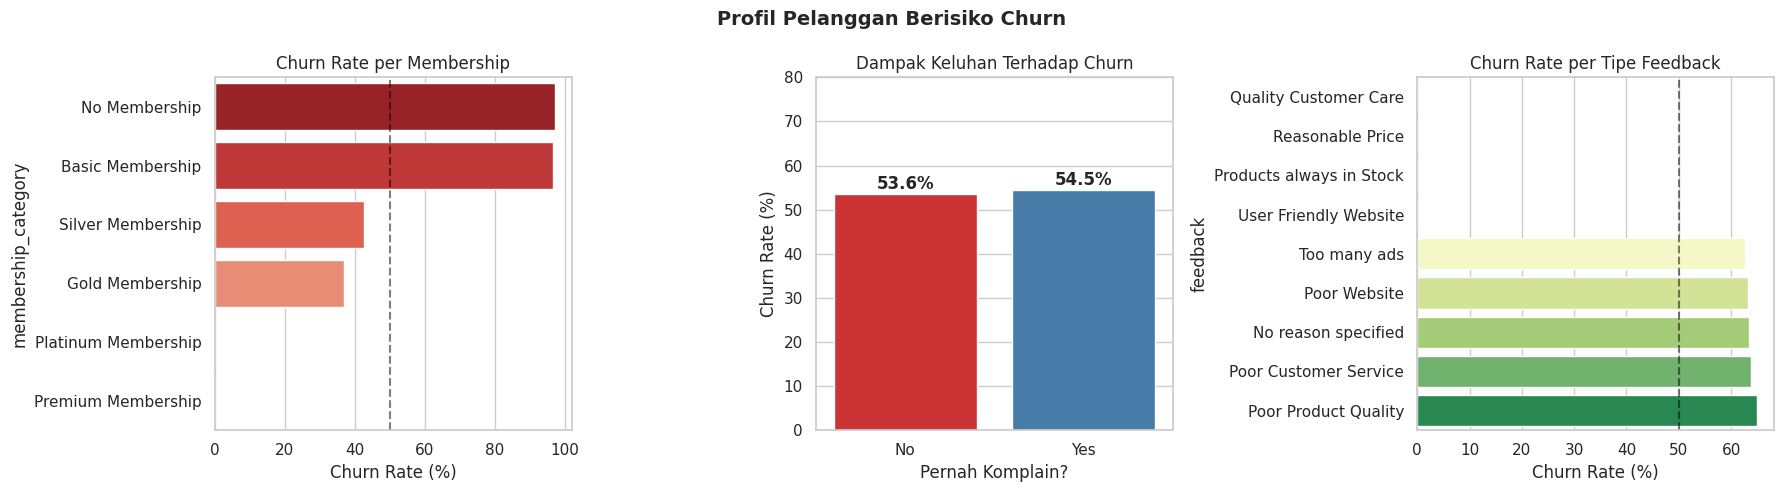

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Churn Rate per Membership Category
churn_by_member = df.groupby('membership_category')['churn_risk_score'].mean().sort_values(ascending=False)
sns.barplot(x=churn_by_member.values * 100, y=churn_by_member.index, palette='Reds_r', ax=axes[0])
axes[0].set_title('Churn Rate per Membership', fontsize=12)
axes[0].set_xlabel('Churn Rate (%)')
axes[0].axvline(50, color='black', linestyle='--', alpha=0.5)

# Plot 2: Churn Rate berdasarkan Riwayat Keluhan (past_complaint)
churn_by_complaint = df.groupby('past_complaint')['churn_risk_score'].mean()
sns.barplot(x=churn_by_complaint.index, y=churn_by_complaint.values * 100, palette='Set1', ax=axes[1])
axes[1].set_title('Dampak Keluhan Terhadap Churn', fontsize=12)
axes[1].set_xlabel('Pernah Komplain?')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 80)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{bar.get_height():.1f}%', ha='center', fontweight='bold')

# Plot 3: Churn Rate berdasarkan Feedback
churn_by_feedback = df.groupby('feedback')['churn_risk_score'].mean().sort_values(ascending=True)
sns.barplot(x=churn_by_feedback.values * 100, y=churn_by_feedback.index, palette='RdYlGn', ax=axes[2])
axes[2].set_title('Churn Rate per Tipe Feedback', fontsize=12)
axes[2].set_xlabel('Churn Rate (%)')
axes[2].axvline(50, color='black', linestyle='--', alpha=0.5)

plt.suptitle('Profil Pelanggan Berisiko Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# INSIGHT — Profil pelanggan berisiko churn:
# 1. 'No Membership' → churn rate tertinggi, tidak ada ikatan loyalitas apapun.
# 2. Pernah komplain (Yes) → risiko churn jauh lebih tinggi.
# 3. Feedback negatif (Poor Customer Service, Poor Website) → sinyal kuat akan churn.

## BAB 3: Data Preparation



### 3.1 Menangani Missing Values
Dari audit di BAB 2, hanya kolom **kategorikal** yang memiliki nilai kosong.
Strategi: isi dengan **modus** (nilai yang paling sering muncul di kolom tersebut).`

In [4]:
# Isi missing value kolom KATEGORIKAL dengan MODUS
df['gender']                  = df['gender'].fillna(df['gender'].mode()[0])
df['region_category']         = df['region_category'].fillna(df['region_category'].mode()[0])
df['joined_through_referral'] = df['joined_through_referral'].fillna(df['joined_through_referral'].mode()[0])
df['medium_of_operation']     = df['medium_of_operation'].fillna(df['medium_of_operation'].mode()[0])
df['preferred_offer_types']   = df['preferred_offer_types'].fillna(df['preferred_offer_types'].mode()[0])

# Verifikasi — tidak boleh ada missing value tersisa
print("Missing values setelah ditangani:")
print(df.isnull().sum().sum(), "missing values tersisa ")

Missing values setelah ditangani:
0 missing values tersisa 


### 3.2 Rekayasa Fitur: Ekstraksi Tenure dari Joining Date
Kolom `joining_date` berisi tanggal bergabung. Informasi ini lebih berguna jika diubah menjadi
**berapa lama pelanggan sudah aktif (tenure dalam bulan)** — fitur yang diminta di target proyek.

In [5]:
# Ubah ke format datetime
df['joining_date'] = pd.to_datetime(df['joining_date'])

# Hitung selisih hari dari tanggal terbaru, lalu konversi ke bulan
tanggal_referensi = df['joining_date'].max()
df['tenure_months'] = ((tanggal_referensi - df['joining_date']).dt.days / 30).astype(int)

print("Statistik Tenure Pelanggan (dalam bulan):")
print(df['tenure_months'].describe())
# INSIGHT: Pelanggan dengan tenure rendah (baru bergabung) cenderung lebih mudah churn
# karena belum memiliki ikatan kuat dengan platform.

Statistik Tenure Pelanggan (dalam bulan):
count    37010.000000
mean        17.680816
std         10.597524
min          0.000000
25%          8.000000
50%         18.000000
75%         27.000000
max         36.000000
Name: tenure_months, dtype: float64


### 3.3 Data Transformation (Encoding)
Algoritma Machine Learning **tidak bisa memproses teks**. Kita ubah semua kolom teks menjadi angka.
* Teks binary ('Yes'/'No', 'M'/'F') → `.map()`
* Teks dengan banyak kategori → `.get_dummies()` (One-Hot Encoding)

In [6]:
# Drop kolom yang tidak dipakai
df = df.drop(columns=['user_id', 'joining_date', 'last_visit_time'])

# Mapping teks binary ke angka
df['gender']                       = df['gender'].map({'M': 1, 'F': 0})
df['joined_through_referral']      = df['joined_through_referral'].map({'Yes': 1, 'No': 0})
df['used_special_discount']        = df['used_special_discount'].map({'Yes': 1, 'No': 0})
df['offer_application_preference'] = df['offer_application_preference'].map({'Yes': 1, 'No': 0})
df['past_complaint']               = df['past_complaint'].map({'Yes': 1, 'No': 0})

# One-Hot Encoding untuk kolom dengan banyak kategori
df = pd.get_dummies(df, columns=[
    'region_category', 'membership_category', 'preferred_offer_types',
    'medium_of_operation', 'internet_option', 'complaint_status', 'feedback'
], drop_first=True)

print("Bentuk data setelah Encoding (semua sudah berupa angka murni):")
display(df.head(3))

Bentuk data setelah Encoding (semua sudah berupa angka murni):


,age,gender,joined_through_referral,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,...,complaint_status_Solved in Follow-up,complaint_status_Unsolved,feedback_Poor Customer Service,feedback_Poor Product Quality,feedback_Poor Website,feedback_Products always in Stock,feedback_Quality Customer Care,feedback_Reasonable Price,feedback_Too many ads,feedback_User Friendly Website
0,29,0,1,4,1184.49,38604.69,10.0,627.48,1,1,...,False,False,False,False,True,False,False,False,False,False
1,50,1,1,11,338.15,7665.66,17.0,575.97,1,0,...,False,False,True,False,False,False,False,False,False,False
2,26,0,0,8,235.14,37671.69,5.0,767.93,1,0,...,False,False,False,False,False,False,False,False,True,False


### 3.4 Pemisahan Fitur (X) dan Target (y)
* **X (Fitur):** Semua variabel pendukung (histori transaksi, keluhan, tenure, dll).
* **y (Target):** Hanya kolom `churn_risk_score` — ini yang akan ditebak oleh mesin.

In [7]:
# X mengambil semua kolom KECUALI 'churn_risk_score'
X = df.drop('churn_risk_score', axis=1)

# y mengambil HANYA kolom target
y = df['churn_risk_score']

print(f"Jumlah Fitur (X) : {X.shape[1]} kolom")
print(f"\nDistribusi Target (y):")
print(y.value_counts())

Jumlah Fitur (X) : 37 kolom

Distribusi Target (y):
churn_risk_score
1    20018
0    16992
Name: count, dtype: int64


### 3.5 Data Splitting (Train Set & Test Set)
Kita bagi data menjadi dua bagian yang tidak boleh bercampur:
* **Train Set (80%):** Untuk melatih algoritma.
* **Test Set (20%):** Data tersembunyi untuk menguji seberapa akurat prediksi algoritma pada data baru.`

In [8]:
# Membelah data (80% Train, 20% Test)
# stratify=y → proporsi Churn/Tidak Churn dijaga sama di kedua set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah Data Latih (Train Set): {X_train.shape[0]} baris")
print(f"Jumlah Data Uji  (Test Set)  : {X_test.shape[0]} baris")

Jumlah Data Latih (Train Set): 29608 baris
Jumlah Data Uji  (Test Set)  : 7402 baris


### 3.6 Menangani Class Imbalance dengan SMOTE

**Masalah:** Model yang dilatih pada data tidak seimbang cenderung bias dan lebih sering
memprediksi kelas mayoritas, sehingga melewatkan banyak pelanggan yang benar-benar akan churn.

**Solusi: SMOTE (Synthetic Minority Over-sampling Technique)**
SMOTE membuat sampel baru yang sintetis (buatan) agar jumlah kedua kelas seimbang.

>  **Aturan Emas:** SMOTE **HANYA** diterapkan pada **Train Set**.
> Test Set tidak boleh disentuh agar evaluasi mencerminkan kondisi nyata.

In [9]:
# Distribusi kelas SEBELUM SMOTE
print("Distribusi kelas SEBELUM SMOTE (Train Set):")
print(y_train.value_counts())

# Terapkan SMOTE hanya pada Train Set
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Distribusi kelas SESUDAH SMOTE
print("\nDistribusi kelas SESUDAH SMOTE (Train Set):")
print(pd.Series(y_train).value_counts())
print("\n Kedua kelas sudah seimbang!")
print(" Test Set TIDAK disentuh — tetap mencerminkan data asli.")

Distribusi kelas SEBELUM SMOTE (Train Set):
churn_risk_score
1    16014
0    13594
Name: count, dtype: int64

Distribusi kelas SESUDAH SMOTE (Train Set):
churn_risk_score
1    16014
0    16014
Name: count, dtype: int64

 Kedua kelas sudah seimbang!
 Test Set TIDAK disentuh — tetap mencerminkan data asli.


## BAB 4: Modeling — Random Forest Classifier

Menggunakan Algoritma **Random Forest** karena paling relevan untuk kasus ini:
* Kuat menangani banyak fitur campuran (numerik + hasil encoding).
* Tidak butuh normalisasi/scaling data.
* Bisa menunjukkan fitur mana yang paling penting (*feature importance*).
* Jarang overfit dibanding Decision Tree tunggal.

**Cara kerja:** Random Forest membuat ratusan Decision Tree secara acak.
Prediksi akhir ditentukan dari **Voting Mayoritas** semua pohon tersebut.

In [10]:
# Inisialisasi dan Training
model_forest = RandomForestClassifier(n_estimators=100, random_state=42)
model_forest.fit(X_train, y_train)

print("Model Random Forest selesai dilatih!")
print(f"   Jumlah pohon dalam hutan : {model_forest.n_estimators}")
print(f"   Jumlah fitur yang dipakai: {model_forest.n_features_in_}")

Model Random Forest selesai dilatih!
   Jumlah pohon dalam hutan : 100
   Jumlah fitur yang dipakai: 37


### 4.1 Membongkar Black-Box: Bagaimana Model Mengambil Keputusan

In [11]:
# Ambil 1 pelanggan dari Test Set untuk disimulasikan
contoh_pelanggan = X_test.iloc[[0]]

# Lihat suara dari 3 pohon pertama
suara_pohon_1 = model_forest.estimators_[0].predict(contoh_pelanggan.values)[0]
suara_pohon_2 = model_forest.estimators_[1].predict(contoh_pelanggan.values)[0]
suara_pohon_3 = model_forest.estimators_[2].predict(contoh_pelanggan.values)[0]

# Keputusan final (voting 100 pohon)
keputusan_final    = model_forest.predict(contoh_pelanggan)[0]
probabilitas_churn = model_forest.predict_proba(contoh_pelanggan)[0][1]

label = {0: 'Tidak Churn', 1: 'Churn'}
print("--- BUKTI DEMOKRASI RANDOM FOREST ---")
print(f"Suara Pohon #1 : {label[suara_pohon_1]}")
print(f"Suara Pohon #2 : {label[suara_pohon_2]}")
print(f"Suara Pohon #3 : {label[suara_pohon_3]}")
print("...")
print(f"Keputusan Final (Voting 100 pohon) : {label[keputusan_final]}")
print(f"Probabilitas Churn                 : {probabilitas_churn * 100:.1f}%")

--- BUKTI DEMOKRASI RANDOM FOREST ---
Suara Pohon #1 : Churn
Suara Pohon #2 : Churn
Suara Pohon #3 : Churn
...
Keputusan Final (Voting 100 pohon) : Churn
Probabilitas Churn                 : 96.0%


/tmp/ipykernel_12571/2075037986.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_df['Importance'], y=importance_df['Fitur'], palette='Reds_r')


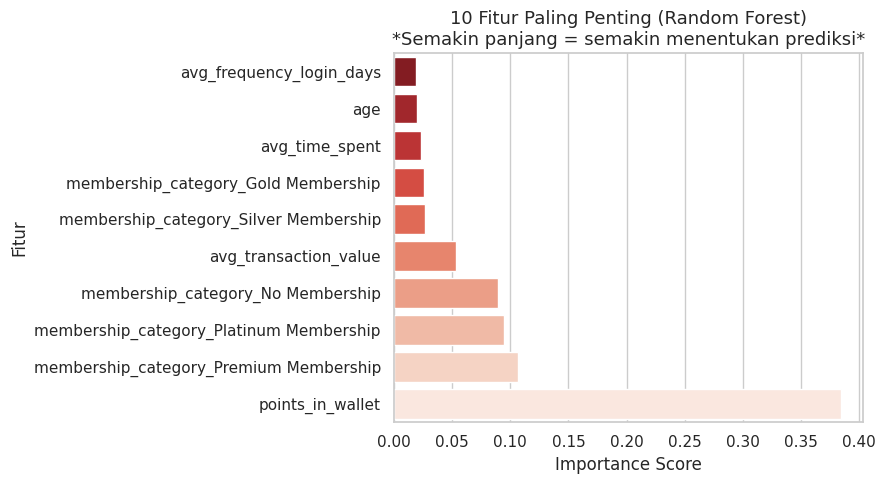

In [12]:
# Feature Importance — fitur mana yang paling sering jadi penentu keputusan
importance_df = pd.DataFrame({
    'Fitur'     : X.columns,
    'Importance': model_forest.feature_importances_
}).sort_values('Importance', ascending=True).tail(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=importance_df['Importance'], y=importance_df['Fitur'], palette='Reds_r')
plt.title('10 Fitur Paling Penting (Random Forest)\n*Semakin panjang = semakin menentukan prediksi*', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# INSIGHT:
# Fitur di urutan teratas adalah yang paling sering dipakai Random Forest
# untuk memutuskan apakah pelanggan akan churn atau tidak.

## BAB 5: Evaluation — Menguji Performa Model

Model sudah dilatih. Sekarang kita uji pada **Test Set** — data yang belum pernah dilihat model.

**Metrik yang kita ukur:**
* **Recall:** % pelanggan Churn yang berhasil terdeteksi → **(Target: ≥ 80%)**
* **Precision:** % prediksi Churn yang benar-benar Churn
* **F1-Score:** Keseimbangan antara Recall dan Precision
* **ROC-AUC:** Kemampuan model membedakan kelas secara keseluruhan

In [13]:
# Prediksi pada Test Set
pred_forest  = model_forest.predict(X_test)
proba_forest = model_forest.predict_proba(X_test)[:, 1]

# Hitung Recall
recall = recall_score(y_test, pred_forest)

print("=" * 50)
print("  HASIL EVALUASI — RANDOM FOREST (Test Set)")
print("=" * 50)
print(f"  Recall  : {recall:.4f}  {'TARGET TERCAPAI!' if recall >= 0.80 else 'Belum mencapai target 0.80'}")
print(f"  ROC-AUC : {roc_auc_score(y_test, proba_forest):.4f}")
print()
print(classification_report(y_test, pred_forest, target_names=['Tidak Churn', 'Churn']))

  HASIL EVALUASI — RANDOM FOREST (Test Set)
  Recall  : 0.9438  TARGET TERCAPAI!
  ROC-AUC : 0.9779

              precision    recall  f1-score   support

 Tidak Churn       0.93      0.92      0.93      3398
       Churn       0.94      0.94      0.94      4004

    accuracy                           0.93      7402
   macro avg       0.93      0.93      0.93      7402
weighted avg       0.93      0.93      0.93      7402



### 5.1 Visualisasi Performa: Confusion Matrix & ROC Curve

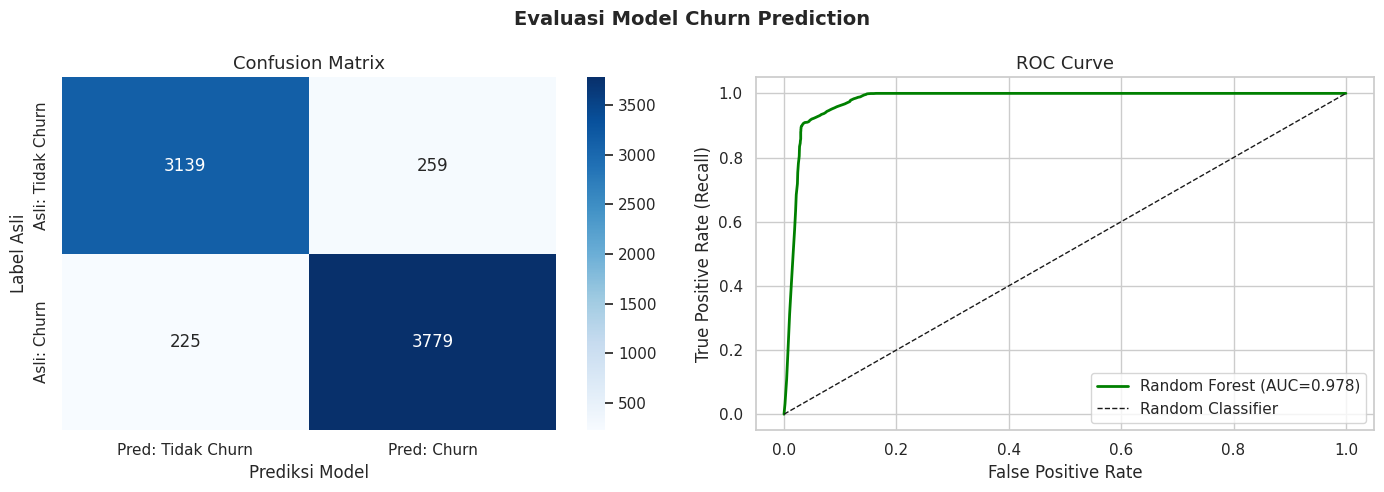

Detail Confusion Matrix:
  True Positive  (TP) : 3779  → Churn yang BERHASIL terdeteksi
  False Negative (FN) : 225  → Churn yang TERLEWAT (paling berbahaya!)
  False Positive (FP) : 259  → Bukan Churn tapi diprediksi Churn
  True Negative  (TN) : 3139  → Tidak Churn dan diprediksi benar

   Recall = 3779 / (3779 + 225) = 0.9438
   Artinya: dari semua pelanggan yang benar-benar Churn,
   model berhasil mendeteksi 94.4%-nya.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafik 1: Confusion Matrix
cm = confusion_matrix(y_test, pred_forest)
tn, fp, fn, tp = cm.ravel()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: Tidak Churn', 'Pred: Churn'],
            yticklabels=['Asli: Tidak Churn', 'Asli: Churn'])
axes[0].set_title('Confusion Matrix', fontsize=13)
axes[0].set_ylabel('Label Asli')
axes[0].set_xlabel('Prediksi Model')

# Grafik 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, proba_forest)
auc = roc_auc_score(y_test, proba_forest)

axes[1].plot(fpr, tpr, color='green', linewidth=2, label=f'Random Forest (AUC={auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].legend()

plt.suptitle('Evaluasi Model Churn Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Detail Confusion Matrix:")
print(f"  True Positive  (TP) : {tp}  → Churn yang BERHASIL terdeteksi")
print(f"  False Negative (FN) : {fn}  → Churn yang TERLEWAT (paling berbahaya!)")
print(f"  False Positive (FP) : {fp}  → Bukan Churn tapi diprediksi Churn")
print(f"  True Negative  (TN) : {tn}  → Tidak Churn dan diprediksi benar")
print()
print(f"   Recall = {tp} / ({tp} + {fn}) = {tp/(tp+fn):.4f}")
print(f"   Artinya: dari semua pelanggan yang benar-benar Churn,")
print(f"   model berhasil mendeteksi {tp/(tp+fn)*100:.1f}%-nya.")

## BAB 6: Simulasi Kerugian Finansial FN vs FP

Angka Recall bersifat abstrak bagi manajemen. Mari terjemahkan ke dalam **bahasa uang**.

**Asumsi:**
* Nilai rata-rata pelanggan (CLV) = Rp 2.000.000 / tahun
* Biaya voucher intervensi = Rp 150.000 / orang

In [15]:
CLV          = 2_000_000   # Rp 2 juta per pelanggan
VOUCHER_COST = 150_000     # Rp 150 ribu per voucher

tn, fp, fn, tp = confusion_matrix(y_test, pred_forest).ravel()

kerugian_fn = fn * CLV           # Churn terlewat → kehilangan pelanggan sepenuhnya
kerugian_fp = fp * VOUCHER_COST  # Voucher dikirim ke yang tidak jadi churn
total       = kerugian_fn + kerugian_fp

print("=" * 55)
print("           SIMULASI DAMPAK FINANSIAL")
print("=" * 55)
print(f"Pelanggan churn TERLEWAT (FN) : {fn} orang")
print(f"  → Estimasi kerugian         : Rp {kerugian_fn:,}")
print()
print(f"Voucher terkirim percuma (FP) : {fp} orang")
print(f"  → Estimasi biaya sia-sia    : Rp {kerugian_fp:,}")
print()
print(f"TOTAL ESTIMASI KERUGIAN       : Rp {total:,}")
print()
print(" INSIGHT: Kerugian dari FN jauh lebih besar dari FP.")
print(" Ini membuktikan mengapa Recall harus dimaksimalkan!")

           SIMULASI DAMPAK FINANSIAL
Pelanggan churn TERLEWAT (FN) : 225 orang
  → Estimasi kerugian         : Rp 450,000,000

Voucher terkirim percuma (FP) : 259 orang
  → Estimasi biaya sia-sia    : Rp 38,850,000

TOTAL ESTIMASI KERUGIAN       : Rp 488,850,000

 INSIGHT: Kerugian dari FN jauh lebih besar dari FP.
 Ini membuktikan mengapa Recall harus dimaksimalkan!


## BAB 7: Rekomendasi Bisnis Otomatis per Segmen

Deteksi saja tidak cukup — tim bisnis butuh tindakan nyata.
Kita segmentasikan pelanggan berdasarkan probabilitas churn dan rekomendasikan intervensi yang tepat.

In [16]:
# Probabilitas churn setiap pelanggan di Test Set
proba_test = model_forest.predict_proba(X_test)[:, 1]

# Buat dataframe hasil prediksi
hasil = pd.DataFrame()
hasil['Probabilitas_Churn_%'] = (proba_test * 100).round(1)
hasil['Label_Asli']           = y_test.values

# Segmentasi berdasarkan probabilitas churn
hasil.loc[hasil['Probabilitas_Churn_%'] >= 75, 'Segmen'] = ' Kritis (>=75%)'
hasil.loc[(hasil['Probabilitas_Churn_%'] >= 50) & (hasil['Probabilitas_Churn_%'] < 75), 'Segmen'] = ' Tinggi (50-74%)'
hasil.loc[(hasil['Probabilitas_Churn_%'] >= 30) & (hasil['Probabilitas_Churn_%'] < 50), 'Segmen'] = ' Sedang (30-49%)'
hasil.loc[hasil['Probabilitas_Churn_%'] < 30,  'Segmen'] = ' Rendah (<30%)'

# Rekomendasi intervensi per segmen
hasil.loc[hasil['Segmen'] == ' Kritis (>=75%)',   'Rekomendasi'] = 'Hubungi CS personal + Diskon 30% eksklusif (dalam 24 jam)'
hasil.loc[hasil['Segmen'] == ' Tinggi (50-74%)',  'Rekomendasi'] = 'Kirim voucher cashback 20%'
hasil.loc[hasil['Segmen'] == ' Sedang (30-49%)',  'Rekomendasi'] = 'Email engagement + Bonus loyalty points 2x'
hasil.loc[hasil['Segmen'] == ' Rendah (<30%)',    'Rekomendasi'] = 'Newsletter rutin + Notifikasi promo biasa'

print("RINGKASAN SEGMENTASI PELANGGAN:")
print(hasil['Segmen'].value_counts().to_string())
print()
print("CONTOH 5 PELANGGAN PRIORITAS INTERVENSI SEGERA:")
display(hasil[hasil['Segmen'] == ' Kritis (>=75%)'].head(5))

RINGKASAN SEGMENTASI PELANGGAN:
Segmen
Kritis (>=75%)     3670
Rendah (<30%)      2921
Sedang (30-49%)     420
Tinggi (50-74%)     391

CONTOH 5 PELANGGAN PRIORITAS INTERVENSI SEGERA:


,Probabilitas_Churn_%,Label_Asli,Segmen,Rekomendasi
0,96.0,1,Kritis (>=75%),Hubungi CS personal + Diskon 30% eksklusif (da...
1,87.0,1,Kritis (>=75%),Hubungi CS personal + Diskon 30% eksklusif (da...
2,92.0,1,Kritis (>=75%),Hubungi CS personal + Diskon 30% eksklusif (da...
4,94.0,1,Kritis (>=75%),Hubungi CS personal + Diskon 30% eksklusif (da...
5,97.0,1,Kritis (>=75%),Hubungi CS personal + Diskon 30% eksklusif (da...
